<a href="https://colab.research.google.com/github/melissa-04/tubitak-2209a-spatial-stemness-emt/blob/main/10_figures_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q "pandas==2.3.3"

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd, numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

BASE    = '/content/drive/MyDrive/Tubitak-2209a'
RESULTS = f'{BASE}/04_results'
FIGURES = f'{BASE}/05_figures'
MAIN    = f'{FIGURES}/main'
os.makedirs(MAIN, exist_ok=True)

mpl.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 8,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'figure.dpi'       : 110,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
})

C = {
    'TNBC'    : '#2C6E8E',
    'ER'      : '#C4622D',
    'cell'    : '#4C72B0',
    'spot'    : '#C44E52',
    'null'    : '#9A9A9A',
    'neutral' : '#4A4A4A',
    'accent'  : '#55828B',
    'light'   : '#D8D8D8',
    'warn'    : '#B03A2E',
}

PATIENTS = ['1142243F', '1160920F', 'CID4290', 'CID4465', 'CID44971', 'CID4535']
SUBTYPE  = {'1142243F':'TNBC', '1160920F':'TNBC', 'CID4290':'ER',
            'CID4465':'TNBC', 'CID44971':'TNBC', 'CID4535':'ER'}
SIG_LABEL = {'pEMT_puram':'Puram p-EMT', 'EMT_hallmark':'Hallmark EMT',
             'EMT_tan':'Tan EMT', 'EMT_tan_mes':'Tan (mesenchymal)',
             'EMT_tan_epi':'Tan (epithelial)'}

def panel(ax, letter, title=''):
    ax.text(-0.14, 1.06, letter, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='bottom', ha='left')
    if title:
        ax.set_title(title, loc='left', pad=8)

R = {}
for f in sorted(os.listdir(RESULTS)):
    if f.endswith('.csv'):
        R[f[:-4]] = pd.read_csv(f'{RESULTS}/{f}')
nulls = np.load(f'{RESULTS}/permutation_nulls.npz')

print(f'Loaded {len(R)} result tables + {len(nulls.files)} null distributions\n')
for k in sorted(R):
    print(f'  {k:38s} {R[k].shape}')

scores  = pd.read_csv(f'{BASE}/03_spatial_analysis/spatial_all_scores.csv')
regions = pd.read_csv(f'{BASE}/01_processed_data/combined_with_regions.csv')
regions['SpotID'] = regions.patientid.astype(str) + '_' + regions.barcode.astype(str)
spots = scores.merge(regions[['SpotID','array_row','array_col']], on='SpotID', how='left')
dist  = R['spot_distances']
spots = spots.merge(dist, on='SpotID', how='left', suffixes=('','_d'))
print(f'\nSpot table for maps: {spots.shape}')
print(f'  with coordinates: {spots.array_row.notna().sum()}')
print(f'  with stemness   : {spots.spatial_stemness.notna().sum()}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 146.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 2.3.3 which is incompatible.
Mounted at /content/drive
Loaded 30 result tables + 18 null distributions

  carried_emt_comparison                 (4, 5)
  carried_emt_shuffle_null               (2, 6)
  cell_level_scores                      (28844, 7)
  cellcycle_controlled_identity          (7, 8)
  cellcycle_controlled_main              (3, 10)
  cytotrace_diagnostics                  (15, 7)
  distance_correlation                   (4, 11)
  frontcore_per_patient                  (24, 10)
  frontcore_summary                      (4, 9)
  invertedU_lowess                       (2, 10)
  invert

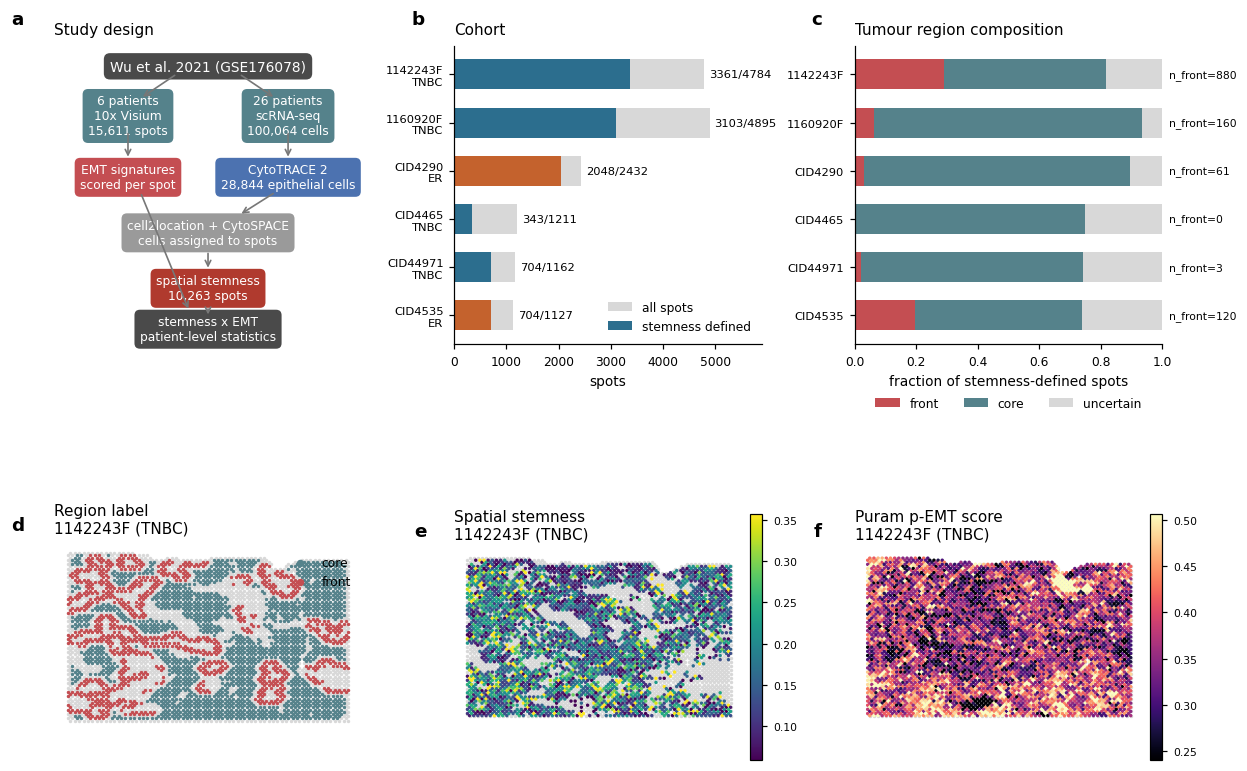

Saved -> /content/drive/MyDrive/Tubitak-2209a/05_figures/main/Fig1_design_and_data.png (+ .pdf)


In [2]:
fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.15], hspace=0.38, wspace=0.30)

ax = fig.add_subplot(gs[0, 0]); panel(ax, 'a', 'Study design')
ax.axis('off')
boxes = [
    (0.50, 0.93, 'Wu et al. 2021 (GSE176078)', C['neutral'], 'white', 9),
    (0.24, 0.76, '6 patients\n10x Visium\n15,611 spots', C['accent'], 'white', 8),
    (0.76, 0.76, '26 patients\nscRNA-seq\n100,064 cells', C['accent'], 'white', 8),
    (0.76, 0.55, 'CytoTRACE 2\n28,844 epithelial cells', C['cell'], 'white', 8),
    (0.50, 0.36, 'cell2location + CytoSPACE\ncells assigned to spots', C['null'], 'white', 8),
    (0.24, 0.55, 'EMT signatures\nscored per spot', C['spot'], 'white', 8),
    (0.50, 0.17, 'spatial stemness\n10,263 spots', C['warn'], 'white', 8),
    (0.50, 0.03, 'stemness x EMT\npatient-level statistics', C['neutral'], 'white', 8),
]
for x, y, t, fc, tc, fs in boxes:
    ax.text(x, y, t, ha='center', va='center', fontsize=fs, color=tc,
            bbox=dict(boxstyle='round,pad=0.45', facecolor=fc, edgecolor='none'))
arrows = [(0.40,0.905,0.28,0.82), (0.60,0.905,0.72,0.82), (0.76,0.71,0.76,0.61),
          (0.24,0.71,0.24,0.61), (0.72,0.50,0.60,0.42), (0.50,0.30,0.50,0.23),
          (0.50,0.11,0.50,0.07), (0.28,0.50,0.44,0.09)]
for x0, y0, x1, y1 in arrows:
    ax.annotate('', xy=(x1,y1), xytext=(x0,y0),
                arrowprops=dict(arrowstyle='->', color='#777', lw=1.1))
ax.set_xlim(0,1); ax.set_ylim(-0.02,1.0)

ax = fig.add_subplot(gs[0, 1]); panel(ax, 'b', 'Cohort')
tot = spots.groupby('patientid').size().reindex(PATIENTS)
stm = spots[spots.spatial_stemness.notna()].groupby('patientid').size().reindex(PATIENTS).fillna(0)
y = np.arange(len(PATIENTS))
ax.barh(y, tot, color=C['light'], height=0.62, label='all spots')
ax.barh(y, stm, color=[C[SUBTYPE[p]] for p in PATIENTS], height=0.62, label='stemness defined')
for i, p in enumerate(PATIENTS):
    ax.text(tot[p] + 90, i, f'{int(stm[p])}/{int(tot[p])}', va='center', fontsize=7.5)
ax.set_yticks(y); ax.set_yticklabels([f'{p}\n{SUBTYPE[p]}' for p in PATIENTS], fontsize=7.5)
ax.invert_yaxis(); ax.set_xlabel('spots'); ax.set_xlim(0, 5900)
ax.legend(loc='lower right', frameon=False)

ax = fig.add_subplot(gs[0, 2]); panel(ax, 'c', 'Tumour region composition')
reg_t = spots[spots.spatial_stemness.notna()].pivot_table(
    index='patientid', columns='tumor_region', aggfunc='size', fill_value=0).reindex(PATIENTS)
for c in ['front','core','uncertain']:
    if c not in reg_t: reg_t[c] = 0
reg_t = reg_t[['front','core','uncertain']]
frac = reg_t.div(reg_t.sum(axis=1), axis=0)
left = np.zeros(len(PATIENTS))
for c, col in zip(['front','core','uncertain'], [C['spot'], C['accent'], C['light']]):
    ax.barh(y, frac[c], left=left, color=col, height=0.62, label=c)
    left += frac[c].values
for i, p in enumerate(PATIENTS):
    ax.text(1.02, i, f"n_front={int(reg_t.loc[p,'front'])}", va='center', fontsize=7)
ax.set_yticks(y); ax.set_yticklabels(PATIENTS, fontsize=7.5)
ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel('fraction of stemness-defined spots')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False)

EX = '1142243F'
ex = spots[(spots.patientid == EX) & spots.array_row.notna()]
maps = [('tumor_region', 'Region label', None),
        ('spatial_stemness', 'Spatial stemness', 'viridis'),
        ('pEMT_puram', 'Puram p-EMT score', 'magma')]
for j, (col, ttl, cmap) in enumerate(maps):
    ax = fig.add_subplot(gs[1, j])
    panel(ax, 'defg'[j], f'{ttl}\n{EX} ({SUBTYPE[EX]})')
    ax.scatter(ex.array_col, -ex.array_row, s=5, c=C['light'], linewidths=0)
    if col == 'tumor_region':
        for lab, cc in [('core', C['accent']), ('front', C['spot'])]:
            m = ex[ex.tumor_region == lab]
            ax.scatter(m.array_col, -m.array_row, s=5, c=cc, linewidths=0, label=lab)
        ax.legend(loc='upper right', frameon=False, markerscale=2.2)
    else:
        m = ex[ex[col].notna()]
        lo, hi = np.nanpercentile(m[col], [5, 95])
        sca = ax.scatter(m.array_col, -m.array_row, s=5, c=m[col],
                         cmap=cmap, vmin=lo, vmax=hi, linewidths=0)
        cb = plt.colorbar(sca, ax=ax, fraction=0.04, pad=0.02)
        cb.ax.tick_params(labelsize=7)
    ax.set_aspect('equal'); ax.axis('off')

fig.savefig(f'{MAIN}/Fig1_design_and_data.png')
fig.savefig(f'{MAIN}/Fig1_design_and_data.pdf')
plt.show()
print(f'Saved -> {MAIN}/Fig1_design_and_data.png (+ .pdf)')

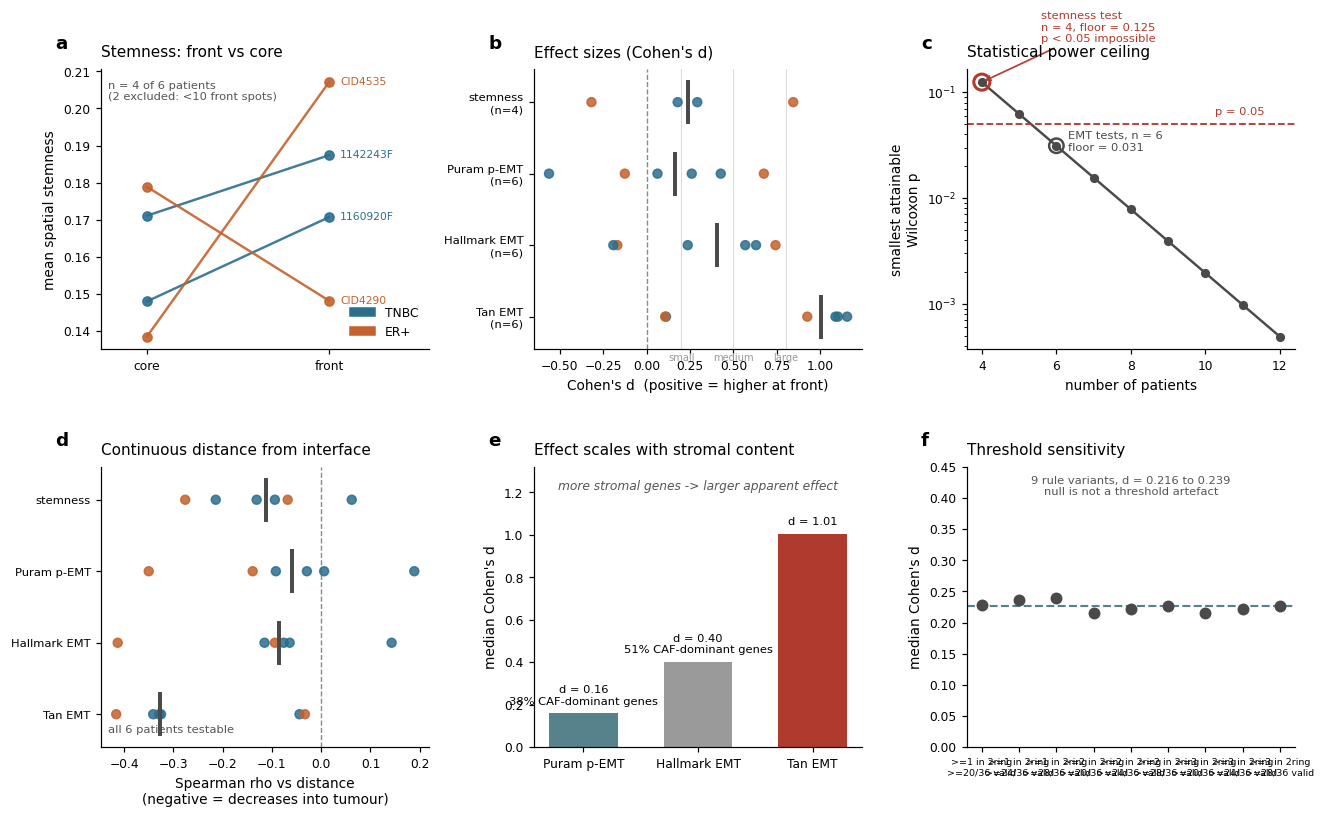

Saved -> /content/drive/MyDrive/Tubitak-2209a/05_figures/main/Fig2_front_vs_core.png (+ .pdf)


In [3]:
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.32)

pp = R['frontcore_per_patient']
sm_fc = R['frontcore_summary']

ax = fig.add_subplot(gs[0, 0]); panel(ax, 'a', 'Stemness: front vs core')
sub = pp[(pp.variable == 'spatial_stemness') & pp.testable]
for _, r in sub.iterrows():
    col = C[SUBTYPE[r.patient]]
    ax.plot([0, 1], [r.mean_core, r.mean_front], marker='o', ms=6,
            color=col, lw=1.6, alpha=0.9)
    ax.text(1.06, r.mean_front, r.patient, fontsize=7, va='center', color=col)
ax.set_xticks([0, 1]); ax.set_xticklabels(['core', 'front'])
ax.set_xlim(-0.25, 1.55); ax.set_ylabel('mean spatial stemness')
ax.text(0.02, 0.96, f'n = {len(sub)} of 6 patients\n(2 excluded: <10 front spots)',
        transform=ax.transAxes, va='top', fontsize=7.5, color='#555')
ax.legend(handles=[Patch(color=C['TNBC'], label='TNBC'), Patch(color=C['ER'], label='ER+')],
          loc='lower right', frameon=False)

ax = fig.add_subplot(gs[0, 1]); panel(ax, 'b', "Effect sizes (Cohen's d)")
order = ['spatial_stemness', 'pEMT_puram', 'EMT_hallmark', 'EMT_tan']
for i, var in enumerate(order):
    s = pp[(pp.variable == var) & pp.testable]
    ax.scatter(s.cohens_d, [i] * len(s), s=34,
               c=[C[SUBTYPE[p]] for p in s.patient], zorder=3, alpha=0.85)
    med = sm_fc[sm_fc.variable == var].median_d.values[0]
    ax.plot([med, med], [i - 0.28, i + 0.28], color=C['neutral'], lw=2.6, zorder=4)
ax.axvline(0, color='#888', lw=0.9, ls='--')
for v, lab in [(0.2, 'small'), (0.5, 'medium'), (0.8, 'large')]:
    ax.axvline(v, color='#DDD', lw=0.7, zorder=0)
    ax.text(v, 3.62, lab, fontsize=6.5, ha='center', color='#999')
ax.set_yticks(range(4))
ax.set_yticklabels(['stemness\n(n=4)', 'Puram p-EMT\n(n=6)',
                    'Hallmark EMT\n(n=6)', 'Tan EMT\n(n=6)'], fontsize=7.5)
ax.invert_yaxis(); ax.set_xlabel("Cohen's d  (positive = higher at front)")

ax = fig.add_subplot(gs[0, 2]); panel(ax, 'c', 'Statistical power ceiling')
ns = np.arange(4, 13)
floor = 2 / 2.0 ** ns
ax.plot(ns, floor, marker='o', ms=5, color=C['neutral'], lw=1.6)
ax.axhline(0.05, color=C['warn'], lw=1.2, ls='--')
ax.text(11.6, 0.062, 'p = 0.05', fontsize=7.5, color=C['warn'], ha='right')
ax.scatter([4], [2/16], s=110, facecolor='none', edgecolor=C['warn'], lw=2, zorder=5)
ax.annotate('stemness test\nn = 4, floor = 0.125\np < 0.05 impossible',
            xy=(4, 2/16), xytext=(5.6, 0.30), fontsize=7.5, color=C['warn'],
            arrowprops=dict(arrowstyle='->', color=C['warn'], lw=1.1))
ax.scatter([6], [2/64], s=90, facecolor='none', edgecolor=C['neutral'], lw=1.6, zorder=5)
ax.text(6.3, 0.028, 'EMT tests, n = 6\nfloor = 0.031', fontsize=7.5, color=C['neutral'])
ax.set_yscale('log'); ax.set_xlabel('number of patients')
ax.set_ylabel('smallest attainable\nWilcoxon p')

ax = fig.add_subplot(gs[1, 0]); panel(ax, 'd', 'Continuous distance from interface')
dc = R['distance_correlation']
for i, var in enumerate(order):
    row = dc[dc.variable == var]
    if not len(row): continue
    vals = [row[p].values[0] for p in PATIENTS if p in row.columns]
    ax.scatter(vals, [i] * len(vals), s=34,
               c=[C[SUBTYPE[p]] for p in PATIENTS if p in row.columns], alpha=0.85, zorder=3)
    ax.plot([row.median_rho.values[0]] * 2, [i - 0.28, i + 0.28],
            color=C['neutral'], lw=2.6, zorder=4)
ax.axvline(0, color='#888', lw=0.9, ls='--')
ax.set_yticks(range(4))
ax.set_yticklabels(['stemness', 'Puram p-EMT', 'Hallmark EMT', 'Tan EMT'], fontsize=7.5)
ax.invert_yaxis(); ax.set_xlabel('Spearman rho vs distance\n(negative = decreases into tumour)')
ax.text(0.02, 0.05, 'all 6 patients testable', transform=ax.transAxes,
        fontsize=7.5, color='#555')

ax = fig.add_subplot(gs[1, 1]); panel(ax, 'e', 'Effect scales with stromal content')
sig3 = ['pEMT_puram', 'EMT_hallmark', 'EMT_tan']
dvals = [sm_fc[sm_fc.variable == s].median_d.values[0] for s in sig3]
caf_frac = [38, 51, None]
bars = ax.bar(range(3), dvals, color=[C['accent'], C['null'], C['warn']], width=0.6)
for i, (v, cf) in enumerate(zip(dvals, caf_frac)):
    lab = f'd = {v:.2f}'
    if cf: lab += f'\n{cf}% CAF-dominant genes'
    ax.text(i, v + 0.04, lab, ha='center', fontsize=7.5)
ax.set_xticks(range(3)); ax.set_xticklabels([SIG_LABEL[s] for s in sig3], fontsize=8)
ax.set_ylabel("median Cohen's d"); ax.set_ylim(0, 1.32)
ax.text(0.5, 0.92, 'more stromal genes -> larger apparent effect',
        transform=ax.transAxes, ha='center', fontsize=8, style='italic', color='#555')

ax = fig.add_subplot(gs[1, 2]); panel(ax, 'f', 'Threshold sensitivity')
th = R['sensitivity_thresholds']
ax.scatter(range(len(th)), th.median_d, s=46, color=C['neutral'], zorder=3)
ax.axhline(np.median(th.median_d), color=C['accent'], lw=1.4, ls='--')
ax.set_xticks(range(len(th)))
ax.set_xticklabels([f"{a}\n{b}" for a, b in zip(th.front_rule, th.core_rule)],
                   fontsize=6.2, rotation=0)
ax.set_ylabel("median Cohen's d"); ax.set_ylim(0, 0.45)
ax.text(0.5, 0.90, '9 rule variants, d = 0.216 to 0.239\nnull is not a threshold artefact',
        transform=ax.transAxes, ha='center', fontsize=7.5, color='#555')

fig.savefig(f'{MAIN}/Fig2_front_vs_core.png')
fig.savefig(f'{MAIN}/Fig2_front_vs_core.pdf')
plt.show()
print(f'Saved -> {MAIN}/Fig2_front_vs_core.png (+ .pdf)')

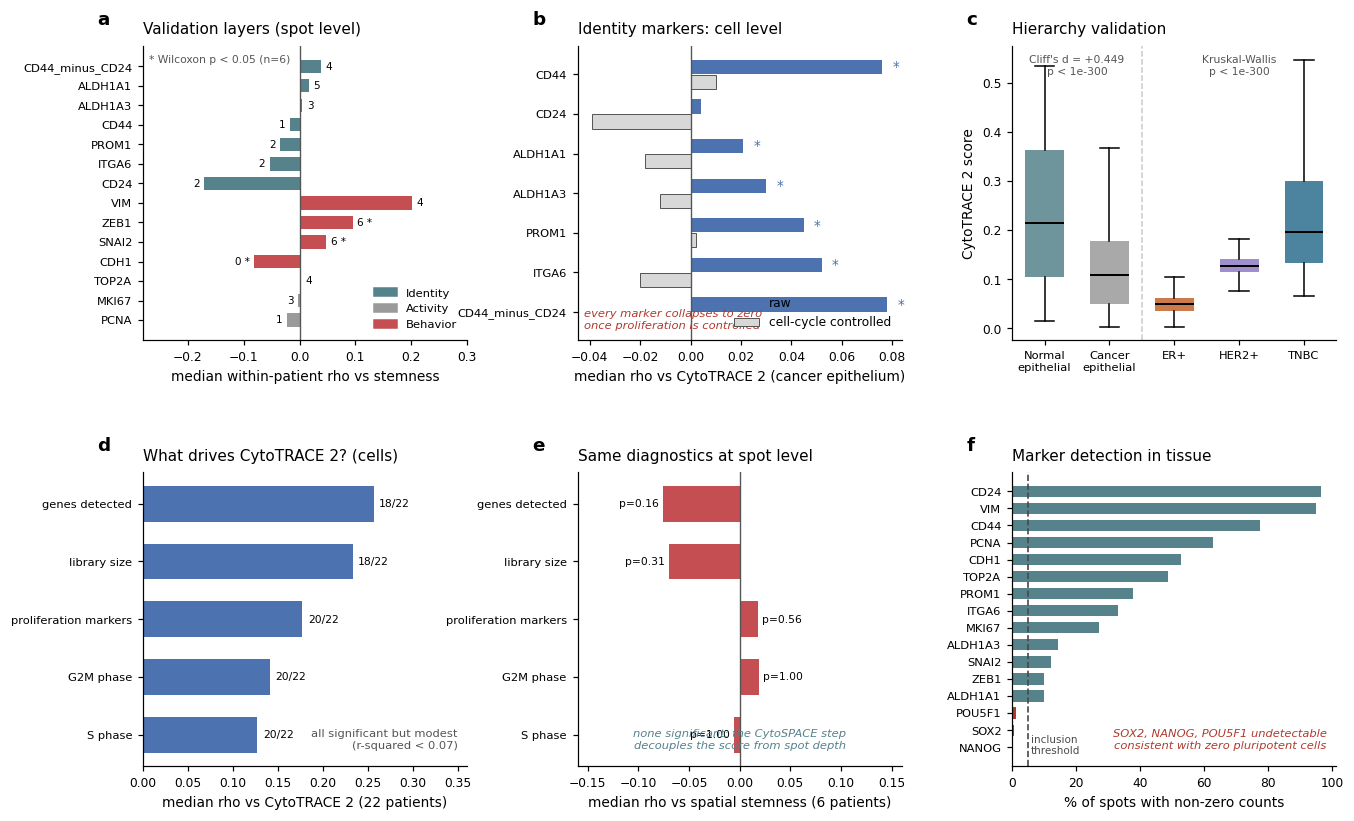

Saved -> /content/drive/MyDrive/Tubitak-2209a/05_figures/main/Fig3_validation.png (+ .pdf)


In [4]:
fig = plt.figure(figsize=(14, 8.5))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.34)

vs = R['validation_spot_level']
LAYER_C = {'Identity': C['accent'], 'Activity': C['null'], 'Behavior': C['spot']}

ax = fig.add_subplot(gs[0, 0]); panel(ax, 'a', 'Validation layers (spot level)')
vs_p = vs[~vs.variable.str.startswith('score_')].copy()
vs_p = vs_p.sort_values(['layer', 'median_r'])
ypos = np.arange(len(vs_p))
ax.barh(ypos, vs_p.median_r, color=[LAYER_C[l] for l in vs_p.layer], height=0.68)
for i, (_, r) in enumerate(vs_p.iterrows()):
    star = ' *' if r.wilcoxon_p < 0.05 else ''
    off = 0.008 if r.median_r >= 0 else -0.008
    ax.text(r.median_r + off, i, f'{r.n_positive}{star}', va='center',
            ha='left' if r.median_r >= 0 else 'right', fontsize=6.8)
ax.axvline(0, color='#555', lw=0.9)
ax.set_yticks(ypos); ax.set_yticklabels(vs_p.variable, fontsize=7.5)
ax.set_xlabel('median within-patient rho vs stemness'); ax.set_xlim(-0.28, 0.30)
ax.legend(handles=[Patch(color=v, label=k) for k, v in LAYER_C.items()],
          loc='lower right', frameon=False, fontsize=7.5)
ax.text(0.02, 0.97, '* Wilcoxon p < 0.05 (n=6)', transform=ax.transAxes,
        fontsize=7, va='top', color='#555')

ax = fig.add_subplot(gs[0, 1]); panel(ax, 'b', 'Identity markers: cell level')
ic = R['cellcycle_controlled_identity']
yp = np.arange(len(ic))
ax.barh(yp - 0.19, ic.raw_r, height=0.36, color=C['cell'], label='raw')
ax.barh(yp + 0.19, ic.partial_r, height=0.36, color=C['light'],
        edgecolor=C['neutral'], lw=0.6, label='cell-cycle controlled')
for i, (_, r) in enumerate(ic.iterrows()):
    if r.raw_p < 0.05:
        ax.text(r.raw_r + 0.004, i - 0.19, '*', va='center', fontsize=9, color=C['cell'])
ax.axvline(0, color='#555', lw=0.9)
ax.set_yticks(yp); ax.set_yticklabels(ic.variable, fontsize=7.5)
ax.invert_yaxis(); ax.set_xlabel('median rho vs CytoTRACE 2 (cancer epithelium)')
ax.legend(loc='lower right', frameon=False)
ax.text(0.02, 0.04, 'every marker collapses to zero\nonce proliferation is controlled',
        transform=ax.transAxes, fontsize=7.5, color=C['warn'], style='italic')

ax = fig.add_subplot(gs[0, 2]); panel(ax, 'c', 'Hierarchy validation')
cl = R['cell_level_scores']
groups = [('Normal\nepithelial', cl[cl.celltype == 'Normal Epithelial'].CT2, C['accent']),
          ('Cancer\nepithelial', cl[cl.celltype == 'Cancer Epithelial'].CT2, C['null'])]
canc = cl[cl.celltype == 'Cancer Epithelial']
for st, col in [('ER+', C['ER']), ('HER2+', '#8E7CC3'), ('TNBC', C['TNBC'])]:
    g = canc[canc.subtype == st].CT2
    if len(g): groups.append((st, g, col))
bp = ax.boxplot([g[1].values for g in groups], widths=0.6, showfliers=False,
                patch_artist=True, medianprops=dict(color='black', lw=1.3))
for patch, g in zip(bp['boxes'], groups):
    patch.set_facecolor(g[2]); patch.set_alpha(0.85); patch.set_edgecolor('none')
ax.set_xticklabels([g[0] for g in groups], fontsize=7.5)
ax.set_ylabel('CytoTRACE 2 score')
ax.axvline(2.5, color='#CCC', lw=1, ls='--')
ax.text(1.5, ax.get_ylim()[1]*0.97, "Cliff's d = +0.449\np < 1e-300", ha='center',
        fontsize=7, va='top', color='#555')
ax.text(4, ax.get_ylim()[1]*0.97, 'Kruskal-Wallis\np < 1e-300', ha='center',
        fontsize=7, va='top', color='#555')

ax = fig.add_subplot(gs[1, 0]); panel(ax, 'd', 'What drives CytoTRACE 2? (cells)')
cd = R['cytotrace_diagnostics']
cc = cd[cd.level == 'cell'].copy()
NAME = {'nFeature':'genes detected', 'nCount':'library size',
        'S_score':'S phase', 'G2M_score':'G2M phase',
        'score_Activity':'proliferation markers'}
cc['lab'] = cc.predictor.map(NAME)
cc = cc.sort_values('median_r')
ax.barh(np.arange(len(cc)), cc.median_r, color=C['cell'], height=0.62)
for i, (_, r) in enumerate(cc.iterrows()):
    ax.text(r.median_r + 0.006, i, f'{r.n_positive}/{r.n_groups}', va='center', fontsize=7)
ax.set_yticks(np.arange(len(cc))); ax.set_yticklabels(cc.lab, fontsize=7.5)
ax.set_xlabel('median rho vs CytoTRACE 2 (22 patients)'); ax.set_xlim(0, 0.36)
ax.text(0.97, 0.06, 'all significant but modest\n(r-squared < 0.07)', transform=ax.transAxes,
        ha='right', fontsize=7.5, color='#555')

ax = fig.add_subplot(gs[1, 1]); panel(ax, 'e', 'Same diagnostics at spot level')
cs = cd[cd.level == 'spot'].copy()
cs['lab'] = cs.predictor.map(NAME)
cs = cs.set_index('lab').reindex(cc.lab).reset_index()
ax.barh(np.arange(len(cs)), cs.median_r, color=C['spot'], height=0.62)
for i, (_, r) in enumerate(cs.iterrows()):
    ax.text(r.median_r + (0.004 if r.median_r >= 0 else -0.004), i,
            f'p={r.wilcoxon_p:.2f}', va='center',
            ha='left' if r.median_r >= 0 else 'right', fontsize=7)
ax.axvline(0, color='#555', lw=0.9)
ax.set_yticks(np.arange(len(cs))); ax.set_yticklabels(cs.lab, fontsize=7.5)
ax.set_xlabel('median rho vs spatial stemness (6 patients)'); ax.set_xlim(-0.16, 0.16)
ax.text(0.5, 0.06, 'none significant: the CytoSPACE step\ndecouples the score from spot depth',
        transform=ax.transAxes, ha='center', fontsize=7.5, color=C['accent'], style='italic')

ax = fig.add_subplot(gs[1, 2]); panel(ax, 'f', 'Marker detection in tissue')
mq = R['marker_qc'].sort_values('spot_detect_pct')
cols = [C['warn'] if not u else C['accent'] for u in mq.usable]
ax.barh(np.arange(len(mq)), mq.spot_detect_pct, color=cols, height=0.66)
ax.axvline(5, color=C['neutral'], lw=1.1, ls='--')
ax.text(5.8, -0.4, 'inclusion\nthreshold', fontsize=6.8, color=C['neutral'])
ax.set_yticks(np.arange(len(mq))); ax.set_yticklabels(mq.gene, fontsize=7.5)
ax.set_xlabel('% of spots with non-zero counts')
ax.text(0.97, 0.06, 'SOX2, NANOG, POU5F1 undetectable\nconsistent with zero pluripotent cells',
        transform=ax.transAxes, ha='right', fontsize=7.5, color=C['warn'], style='italic')

fig.savefig(f'{MAIN}/Fig3_validation.png')
fig.savefig(f'{MAIN}/Fig3_validation.pdf')
plt.show()
print(f'Saved -> {MAIN}/Fig3_validation.png (+ .pdf)')

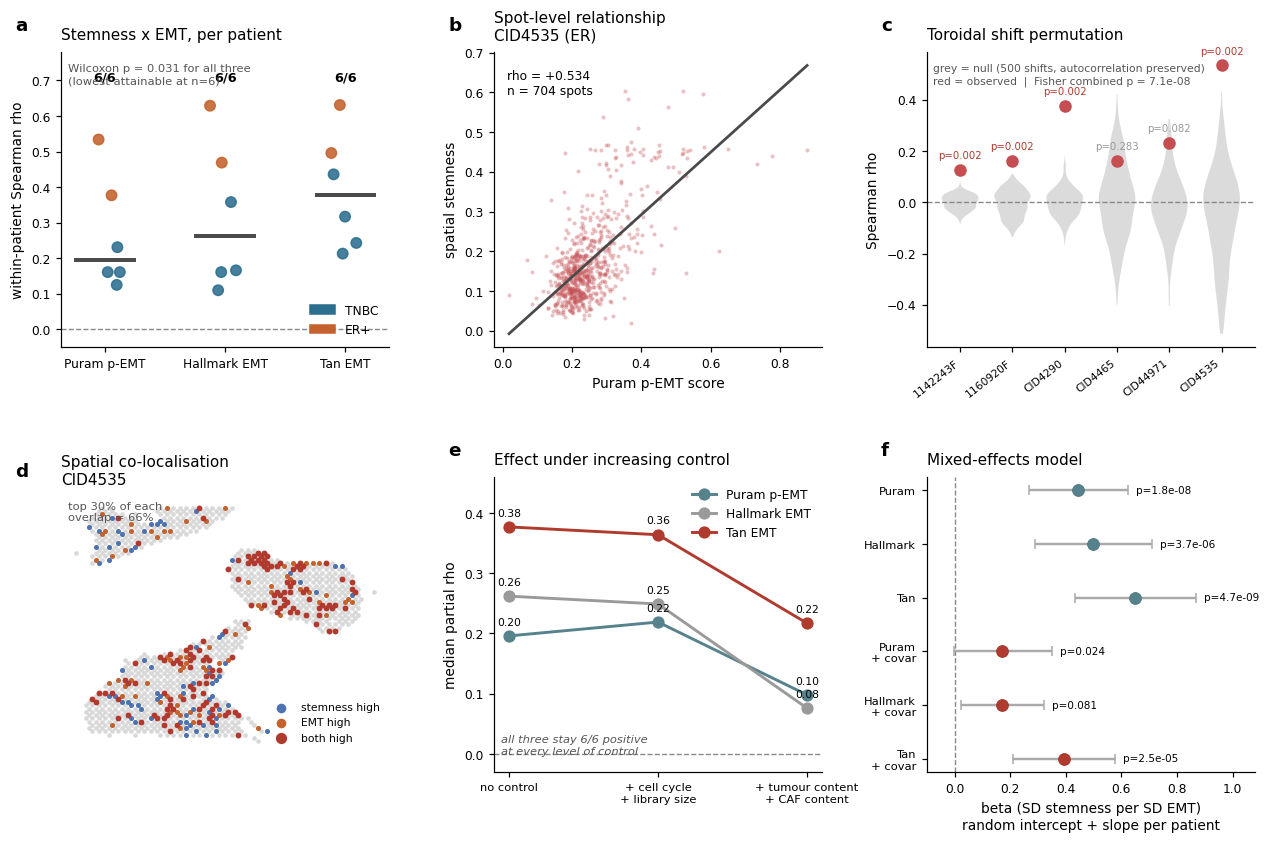

Saved -> /content/drive/MyDrive/Tubitak-2209a/05_figures/main/Fig4_main_finding.png (+ .pdf)


In [5]:
fig = plt.figure(figsize=(14, 8.5))
gs = fig.add_gridspec(2, 3, hspace=0.44, wspace=0.32)

perm = R['spatial_permutation']
SIG3 = ['pEMT_puram', 'EMT_hallmark', 'EMT_tan']

ax = fig.add_subplot(gs[0, 0]); panel(ax, 'a', 'Stemness x EMT, per patient')
for i, sig in enumerate(SIG3):
    s = perm[perm.signature == sig]
    xs = np.random.RandomState(i).normal(i, 0.055, len(s))
    ax.scatter(xs, s.observed_rho, s=46,
               c=[C[SUBTYPE[p]] for p in s.patient], zorder=3, alpha=0.88)
    ax.plot([i - 0.24, i + 0.24], [s.observed_rho.median()] * 2,
            color=C['neutral'], lw=2.6, zorder=4)
    ax.text(i, 0.70, f'{(s.observed_rho > 0).sum()}/6', ha='center', fontsize=8.5,
            fontweight='bold')
ax.axhline(0, color='#888', lw=0.9, ls='--')
ax.set_xticks(range(3)); ax.set_xticklabels([SIG_LABEL[s] for s in SIG3], fontsize=8)
ax.set_ylabel('within-patient Spearman rho'); ax.set_ylim(-0.05, 0.78)
ax.text(0.02, 0.96, 'Wilcoxon p = 0.031 for all three\n(lowest attainable at n=6)',
        transform=ax.transAxes, va='top', fontsize=7.5, color='#555')
ax.legend(handles=[Patch(color=C['TNBC'], label='TNBC'), Patch(color=C['ER'], label='ER+')],
          loc='lower right', frameon=False)

EXA = 'CID4535'
ex = spots[(spots.patientid == EXA) & spots.spatial_stemness.notna()]
ax = fig.add_subplot(gs[0, 1]); panel(ax, 'b', f'Spot-level relationship\n{EXA} ({SUBTYPE[EXA]})')
ax.scatter(ex.pEMT_puram, ex.spatial_stemness, s=7, c=C['spot'], alpha=0.35, linewidths=0)
z = np.polyfit(ex.pEMT_puram, ex.spatial_stemness, 1)
xx = np.linspace(ex.pEMT_puram.min(), ex.pEMT_puram.max(), 50)
ax.plot(xx, np.polyval(z, xx), color=C['neutral'], lw=1.8)
r_ex = perm[(perm.signature == 'pEMT_puram') & (perm.patient == EXA)].observed_rho.values[0]
ax.text(0.04, 0.94, f'rho = {r_ex:+.3f}\nn = {len(ex)} spots', transform=ax.transAxes,
        va='top', fontsize=8)
ax.set_xlabel('Puram p-EMT score'); ax.set_ylabel('spatial stemness')

ax = fig.add_subplot(gs[0, 2]); panel(ax, 'c', 'Toroidal shift permutation')
for i, p in enumerate(PATIENTS):
    key = f'pEMT_puram__{p}'
    if key not in nulls.files: continue
    nd = nulls[key]
    v = ax.violinplot(nd, positions=[i], widths=0.7, showextrema=False)
    for b in v['bodies']:
        b.set_facecolor(C['light']); b.set_alpha(0.9); b.set_edgecolor('none')
    obs = perm[(perm.signature == 'pEMT_puram') & (perm.patient == p)]
    pv = obs.p_spatial.values[0]
    ax.scatter([i], obs.observed_rho.values, s=52, color=C['spot'], zorder=5)
    ax.text(i, obs.observed_rho.values[0] + 0.045,
            f'p={pv:.3f}' if pv >= 0.001 else 'p<0.001',
            ha='center', fontsize=6.6, color=C['warn'] if pv < 0.05 else '#999')
ax.axhline(0, color='#888', lw=0.9, ls='--')
ax.set_xticks(range(6)); ax.set_xticklabels(PATIENTS, rotation=38, ha='right', fontsize=7)
ax.set_ylabel('Spearman rho')
ax.text(0.02, 0.96, 'grey = null (500 shifts, autocorrelation preserved)\n'
                    'red = observed  |  Fisher combined p = 7.1e-08',
        transform=ax.transAxes, va='top', fontsize=7, color='#555')

ax = fig.add_subplot(gs[1, 0]); panel(ax, 'd', f'Spatial co-localisation\n{EXA}')
exa = spots[(spots.patientid == EXA) & spots.array_row.notna()]
ax.scatter(exa.array_col, -exa.array_row, s=9, c=C['light'], linewidths=0)
m = exa[exa.spatial_stemness.notna()]
hs = m.spatial_stemness > m.spatial_stemness.quantile(0.7)
he = m.pEMT_puram > m.pEMT_puram.quantile(0.7)
ax.scatter(m[hs & ~he].array_col, -m[hs & ~he].array_row, s=11, c=C['cell'],
           linewidths=0, label='stemness high')
ax.scatter(m[~hs & he].array_col, -m[~hs & he].array_row, s=11, c=C['ER'],
           linewidths=0, label='EMT high')
ax.scatter(m[hs & he].array_col, -m[hs & he].array_row, s=15, c=C['warn'],
           linewidths=0, label='both high')
ax.set_aspect('equal'); ax.axis('off')
ax.legend(loc='lower right', frameon=False, markerscale=1.9, fontsize=7)
ov = (hs & he).sum() / max(hs.sum(), 1)
ax.text(0.02, 0.98, f'top 30% of each\noverlap = {100*ov:.0f}%', transform=ax.transAxes,
        va='top', fontsize=7.5, color='#555')

ax = fig.add_subplot(gs[1, 1]); panel(ax, 'e', 'Effect under increasing control')
cc_main = R['cellcycle_controlled_main']
steps = ['raw_r', 'cycle_r', 'full_r']
labels = ['no control', '+ cell cycle\n+ library size', '+ tumour content\n+ CAF content']
for i, sig in enumerate(SIG3):
    row = cc_main[cc_main.signature == sig]
    if not len(row): continue
    vals = [row[s].values[0] for s in steps]
    ax.plot(range(3), vals, marker='o', ms=7, lw=1.9,
            color=[C['accent'], C['null'], C['warn']][i], label=SIG_LABEL[sig])
    for j, v in enumerate(vals):
        ax.text(j, v + 0.018, f'{v:.2f}', ha='center', fontsize=7)
ax.axhline(0, color='#888', lw=0.9, ls='--')
ax.set_xticks(range(3)); ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylabel('median partial rho'); ax.set_ylim(-0.03, 0.46)
ax.legend(frameon=False, loc='upper right')
ax.text(0.02, 0.06, 'all three stay 6/6 positive\nat every level of control',
        transform=ax.transAxes, fontsize=7.5, color='#555', style='italic')

ax = fig.add_subplot(gs[1, 2]); panel(ax, 'f', 'Mixed-effects model')
mm = pd.DataFrame({
    'model': ['Puram', 'Hallmark', 'Tan', 'Puram\n+ covar', 'Hallmark\n+ covar', 'Tan\n+ covar'],
    'beta' : [0.4448, 0.4988, 0.6495, 0.1705, 0.1692, 0.3941],
    'lo'   : [0.268, 0.288, 0.432, -0.004, 0.023, 0.211],
    'hi'   : [0.622, 0.710, 0.867, 0.350, 0.320, 0.577],
    'p'    : [1.78e-08, 3.69e-06, 4.68e-09, 0.0236, 0.0809, 2.49e-05]})
yy = np.arange(len(mm))
cols = [C['accent']] * 3 + [C['warn']] * 3
ax.errorbar(mm.beta, yy, xerr=[mm.beta - mm.lo, mm.hi - mm.beta], fmt='o',
            ms=7, color=C['neutral'], ecolor='#AAA', elinewidth=1.6, capsize=3, zorder=3)
for i, c in enumerate(cols):
    ax.scatter(mm.beta[i], i, s=52, color=c, zorder=4)
for i, r in mm.iterrows():
    ax.text(r.hi + 0.03, i, f'p={r.p:.1e}' if r.p < 0.01 else f'p={r.p:.3f}',
            va='center', fontsize=6.8)
ax.axvline(0, color='#888', lw=0.9, ls='--')
ax.set_yticks(yy); ax.set_yticklabels(mm.model, fontsize=7.5)
ax.invert_yaxis(); ax.set_xlim(-0.1, 1.08)
ax.set_xlabel('beta (SD stemness per SD EMT)\nrandom intercept + slope per patient')

fig.savefig(f'{MAIN}/Fig4_main_finding.png')
fig.savefig(f'{MAIN}/Fig4_main_finding.pdf')
plt.show()
print(f'Saved -> {MAIN}/Fig4_main_finding.png (+ .pdf)')

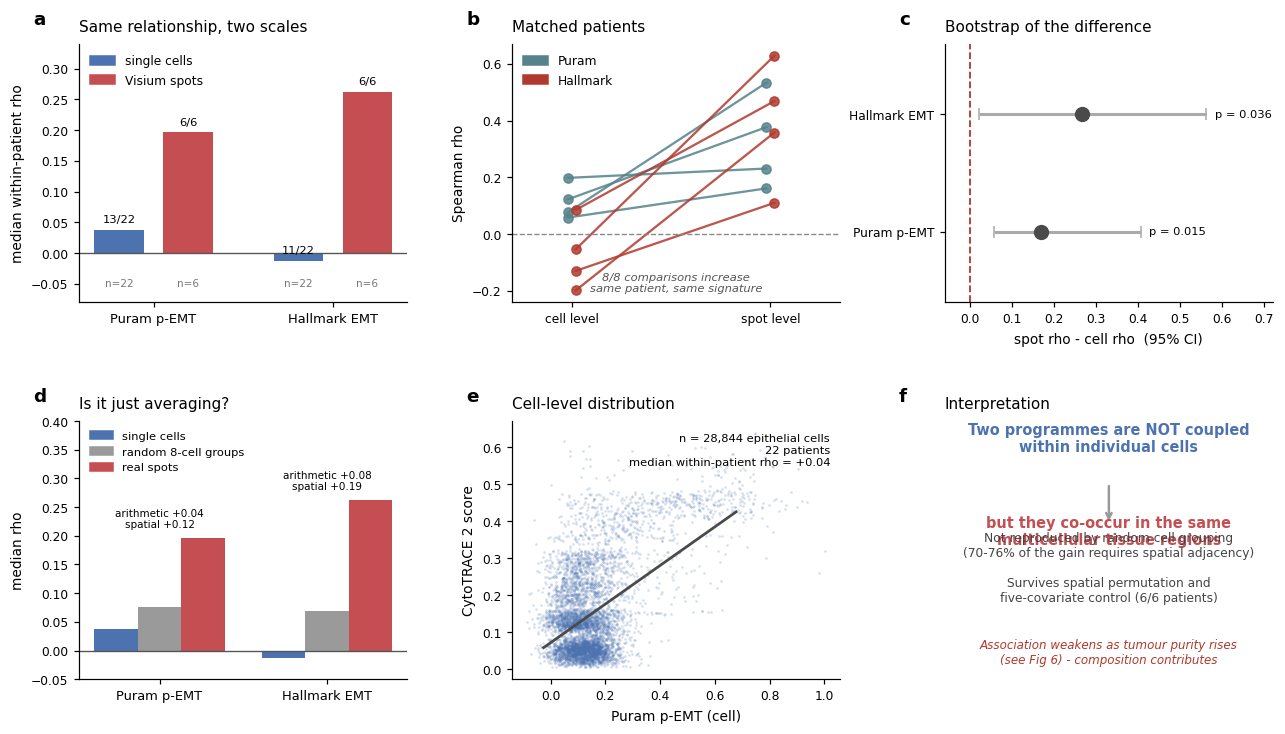

Saved -> /content/drive/MyDrive/Tubitak-2209a/05_figures/main/Fig5_scale_dependence.png (+ .pdf)


In [6]:
fig = plt.figure(figsize=(14, 7.5))
gs = fig.add_gridspec(2, 3, hspace=0.46, wspace=0.32)

sc_cmp = R['scale_comparison']
sc_mat = R['scale_matched_patients']
boot   = R['scale_bootstrap']
pseudo = R['pseudospot_control']
cell   = R['cell_level_scores']

ax = fig.add_subplot(gs[0, 0]); panel(ax, 'a', 'Same relationship, two scales')
for i, sig in enumerate(['pEMT_puram', 'EMT_hallmark']):
    for j, (lvl, col) in enumerate([('cell_all_epithelium', C['cell']), ('spot', C['spot'])]):
        row = sc_cmp[(sc_cmp.signature == sig) & (sc_cmp.level == lvl)]
        if not len(row): continue
        x = i * 2.6 + j
        ax.bar(x, row.median_rho.values[0], width=0.72, color=col)
        ax.text(x, row.median_rho.values[0] + 0.012,
                f"{row.n_positive.values[0]}", ha='center', fontsize=7.5)
        ax.text(x, -0.055, f"n={row.n_units.values[0]}", ha='center', fontsize=6.8, color='#777')
ax.axhline(0, color='#555', lw=0.9)
ax.set_xticks([0.5, 3.1]); ax.set_xticklabels(['Puram p-EMT', 'Hallmark EMT'], fontsize=8.5)
ax.set_ylabel('median within-patient rho'); ax.set_ylim(-0.08, 0.34)
ax.legend(handles=[Patch(color=C['cell'], label='single cells'),
                   Patch(color=C['spot'], label='Visium spots')],
          frameon=False, loc='upper left')

ax = fig.add_subplot(gs[0, 1]); panel(ax, 'b', 'Matched patients')
for sig, col, off in [('pEMT_puram', C['accent'], -0.02), ('EMT_hallmark', C['warn'], 0.02)]:
    s = sc_mat[sc_mat.signature == sig]
    for _, r in s.iterrows():
        ax.plot([0 + off, 1 + off], [r.cell_rho, r.spot_rho], marker='o', ms=6,
                color=col, lw=1.5, alpha=0.85)
ax.axhline(0, color='#888', lw=0.9, ls='--')
ax.set_xticks([0, 1]); ax.set_xticklabels(['cell level', 'spot level'])
ax.set_xlim(-0.3, 1.35); ax.set_ylabel('Spearman rho')
ax.legend(handles=[Patch(color=C['accent'], label='Puram'), Patch(color=C['warn'], label='Hallmark')],
          frameon=False, loc='upper left')
ax.text(0.5, 0.04, '8/8 comparisons increase\nsame patient, same signature',
        transform=ax.transAxes, ha='center', fontsize=7.5, color='#555', style='italic')

ax = fig.add_subplot(gs[0, 2]); panel(ax, 'c', 'Bootstrap of the difference')
for i, (_, r) in enumerate(boot.iterrows()):
    ax.errorbar(r.difference, i, xerr=[[r.difference - r.ci_low], [r.ci_high - r.difference]],
                fmt='o', ms=9, color=C['neutral'], ecolor='#AAA', elinewidth=2, capsize=4)
    ax.text(r.ci_high + 0.02, i, f'p = {r.p_bootstrap:.3f}', va='center', fontsize=7.5)
ax.axvline(0, color=C['warn'], lw=1.2, ls='--')
ax.set_yticks(range(len(boot))); ax.set_yticklabels([SIG_LABEL[s] for s in boot.signature], fontsize=8)
ax.set_ylim(-0.6, 1.6); ax.set_xlim(-0.06, 0.72)
ax.set_xlabel('spot rho - cell rho  (95% CI)')

ax = fig.add_subplot(gs[1, 0]); panel(ax, 'd', 'Is it just averaging?')
w = 0.26
for i, (_, r) in enumerate(pseudo.iterrows()):
    ax.bar(i - w, r.real_cell,   width=w, color=C['cell'])
    ax.bar(i,     r.pseudo_spot, width=w, color=C['null'])
    ax.bar(i + w, r.real_spot,   width=w, color=C['spot'])
    ax.text(i, r.real_spot + 0.018, f"arithmetic {r.gain_arithmetic:+.2f}\nspatial {r.gain_spatial:+.2f}",
            ha='center', fontsize=6.8)
ax.axhline(0, color='#555', lw=0.9)
ax.set_xticks(range(len(pseudo)))
ax.set_xticklabels([SIG_LABEL[s] for s in pseudo.signature], fontsize=8.5)
ax.set_ylabel('median rho'); ax.set_ylim(-0.05, 0.40)
ax.legend(handles=[Patch(color=C['cell'], label='single cells'),
                   Patch(color=C['null'], label='random 8-cell groups'),
                   Patch(color=C['spot'], label='real spots')],
          frameon=False, loc='upper left', fontsize=7.5)

ax = fig.add_subplot(gs[1, 1]); panel(ax, 'e', 'Cell-level distribution')
sub = cell.dropna(subset=['CT2', 'pEMT_puram'])
samp = sub.sample(min(6000, len(sub)), random_state=1)
ax.scatter(samp.pEMT_puram, samp.CT2, s=3, c=C['cell'], alpha=0.22, linewidths=0)
z = np.polyfit(sub.pEMT_puram, sub.CT2, 1)
xx = np.linspace(sub.pEMT_puram.quantile(0.01), sub.pEMT_puram.quantile(0.99), 40)
ax.plot(xx, np.polyval(z, xx), color=C['neutral'], lw=1.8)
ax.set_xlabel('Puram p-EMT (cell)'); ax.set_ylabel('CytoTRACE 2 score')
ax.text(0.97, 0.95, f'n = {len(sub):,} epithelial cells\n22 patients\nmedian within-patient rho = +0.04',
        transform=ax.transAxes, ha='right', va='top', fontsize=7.5)

ax = fig.add_subplot(gs[1, 2]); panel(ax, 'f', 'Interpretation')
ax.axis('off')
ax.text(0.5, 0.88, 'Two programmes are NOT coupled\nwithin individual cells',
        ha='center', fontsize=9.5, color=C['cell'], fontweight='bold')
ax.annotate('', xy=(0.5, 0.60), xytext=(0.5, 0.76),
            arrowprops=dict(arrowstyle='->', color='#999', lw=1.6))
ax.text(0.5, 0.52, 'but they co-occur in the same\nmulticellular tissue regions',
        ha='center', fontsize=9.5, color=C['spot'], fontweight='bold')
ax.text(0.5, 0.30,
        'Not reproduced by random cell grouping\n'
        '(70-76% of the gain requires spatial adjacency)\n\n'
        'Survives spatial permutation and\nfive-covariate control (6/6 patients)',
        ha='center', fontsize=8, color='#444')
ax.text(0.5, 0.06, 'Association weakens as tumour purity rises\n(see Fig 6) - composition contributes',
        ha='center', fontsize=7.8, color=C['warn'], style='italic')

fig.savefig(f'{MAIN}/Fig5_scale_dependence.png')
fig.savefig(f'{MAIN}/Fig5_scale_dependence.pdf')
plt.show()
print(f'Saved -> {MAIN}/Fig5_scale_dependence.png (+ .pdf)')

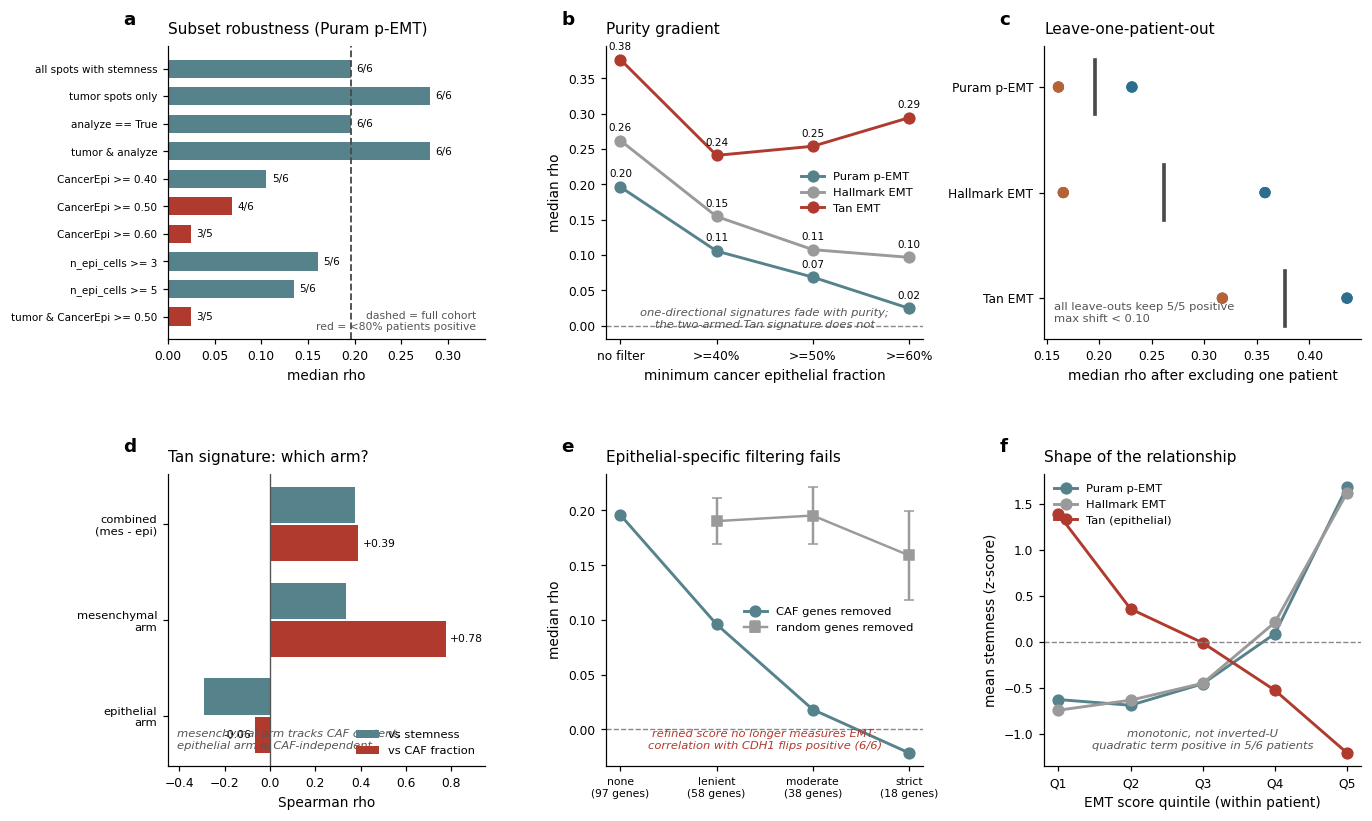

Saved -> /content/drive/MyDrive/Tubitak-2209a/05_figures/main/Fig6_robustness.png (+ .pdf)

ALL SIX MAIN FIGURES COMPLETE
  Fig1_design_and_data.pdf
  Fig1_design_and_data.png
  Fig2_front_vs_core.pdf
  Fig2_front_vs_core.png
  Fig3_validation.pdf
  Fig3_validation.png
  Fig4_main_finding.pdf
  Fig4_main_finding.png
  Fig5_scale_dependence.pdf
  Fig5_scale_dependence.png
  Fig6_robustness.pdf
  Fig6_robustness.png


In [9]:
fig = plt.figure(figsize=(14, 8.5))
gs = fig.add_gridspec(2, 3, hspace=0.46, wspace=0.38)

sens = R['sensitivity_subsets']
loo  = R['sensitivity_leave_one_out']
tan  = R['sensitivity_tan_arms']
ref  = R['refined_signature']
quin = R['invertedU_quintiles']
sbt  = R['sensitivity_subtype']

ax = fig.add_subplot(gs[0, 0]); panel(ax, 'a', 'Subset robustness (Puram p-EMT)')
s = sens[sens.signature == 'pEMT_puram'].copy()
s['npos'] = s.n_positive.str.split('/').str[0].astype(int)
s['ntot'] = s.n_positive.str.split('/').str[1].astype(int)
s = s.iloc[::-1].reset_index(drop=True)
cols = [C['warn'] if (r.npos / r.ntot) < 0.8 else C['accent'] for _, r in s.iterrows()]
ax.barh(np.arange(len(s)), s.median_rho, color=cols, height=0.66)
for i, r in s.iterrows():
    ax.text(r.median_rho + 0.006, i, f'{r.n_positive}', va='center', fontsize=6.8)
ax.axvline(s[s.analysis == 'all spots with stemness'].median_rho.values[0],
           color=C['neutral'], lw=1.2, ls='--')
ax.set_yticks(np.arange(len(s))); ax.set_yticklabels(s.analysis, fontsize=6.8)
ax.set_xlabel('median rho'); ax.set_xlim(0, 0.34)
ax.text(0.97, 0.03, 'dashed = full cohort\nred = <80% patients positive',
        transform=ax.transAxes, ha='right', fontsize=7, color='#555')

ax = fig.add_subplot(gs[0, 1]); panel(ax, 'b', 'Purity gradient')
pur = ['all spots with stemness', 'CancerEpi >= 0.40', 'CancerEpi >= 0.50', 'CancerEpi >= 0.60']
xlab = ['no filter', '>=40%', '>=50%', '>=60%']
for sig, col in [('pEMT_puram', C['accent']), ('EMT_hallmark', C['null']), ('EMT_tan', C['warn'])]:
    v = [sens[(sens.signature == sig) & (sens.analysis == p)].median_rho.values[0] for p in pur]
    ax.plot(range(4), v, marker='o', ms=7, lw=1.9, color=col, label=SIG_LABEL[sig])
    for j, y in enumerate(v):
        ax.text(j, y + 0.014, f'{y:.2f}', ha='center', fontsize=6.8)
ax.axhline(0, color='#888', lw=0.9, ls='--')
ax.set_xticks(range(4)); ax.set_xticklabels(xlab, fontsize=8)
ax.set_xlabel('minimum cancer epithelial fraction')
ax.set_ylabel('median rho'); ax.legend(frameon=False, fontsize=7.5)
ax.text(0.5, 0.04, 'one-directional signatures fade with purity;\n'
                   'the two-armed Tan signature does not',
        transform=ax.transAxes, ha='center', fontsize=7.5, color='#555', style='italic')

ax = fig.add_subplot(gs[0, 2]); panel(ax, 'c', 'Leave-one-patient-out')
for i, sig in enumerate(['pEMT_puram', 'EMT_hallmark', 'EMT_tan']):
    l = loo[loo.signature == sig]
    ax.scatter(l.median_rho, [i] * len(l), s=40,
               c=[C[SUBTYPE[p]] for p in l.excluded], zorder=3, alpha=0.88)
    full = sens[(sens.signature == sig) & (sens.analysis == 'all spots with stemness')].median_rho.values[0]
    ax.plot([full] * 2, [i - 0.26, i + 0.26], color=C['neutral'], lw=2.4, zorder=4)
ax.set_yticks(range(3)); ax.set_yticklabels([SIG_LABEL[s] for s in ['pEMT_puram','EMT_hallmark','EMT_tan']], fontsize=8)
ax.invert_yaxis(); ax.set_xlabel('median rho after excluding one patient')
ax.text(0.03, 0.06, 'all leave-outs keep 5/5 positive\nmax shift < 0.10',
        transform=ax.transAxes, fontsize=7.5, color='#555')

ax = fig.add_subplot(gs[1, 0]); panel(ax, 'd', 'Tan signature: which arm?')
yy = np.arange(len(tan))
ax.barh(yy - 0.2, tan.median_rho, height=0.38, color=C['accent'], label='vs stemness')
ax.barh(yy + 0.2, tan.vs_CAF, height=0.38, color=C['warn'], label='vs CAF fraction')
for i, r in tan.iterrows():
    ax.text(r.vs_CAF + (0.02 if r.vs_CAF >= 0 else -0.02), i + 0.2,
            f'{r.vs_CAF:+.2f}', va='center', fontsize=7,
            ha='left' if r.vs_CAF >= 0 else 'right')
ax.axvline(0, color='#555', lw=0.9)
ax.set_yticks(yy)
ax.set_yticklabels(['combined\n(mes - epi)', 'mesenchymal\narm', 'epithelial\narm'], fontsize=7.5)
ax.invert_yaxis(); ax.set_xlabel('Spearman rho'); ax.set_xlim(-0.45, 0.95)
ax.legend(frameon=False, loc='lower right', fontsize=7.5)
ax.text(0.03, 0.06, 'mesenchymal arm tracks CAF content;\n'
                    'epithelial arm is CAF-independent',
        transform=ax.transAxes, fontsize=7.5, color='#555', style='italic')

ax = fig.add_subplot(gs[1, 1]); panel(ax, 'e', 'Epithelial-specific filtering fails')
rp = ref[ref.signature == 'pEMT_puram']
xs = np.arange(len(rp))
ax.plot(xs, rp.median_rho, marker='o', ms=7, lw=1.9, color=C['accent'], label='CAF genes removed')
rc = rp.dropna(subset=['random_ctrl_median'])
ax.errorbar(np.arange(1, 1 + len(rc)), rc.random_ctrl_median,
            yerr=rc.random_ctrl_sd, marker='s', ms=6, lw=1.6,
            color=C['null'], ecolor=C['null'], capsize=3, label='random genes removed')
ax.axhline(0, color='#888', lw=0.9, ls='--')
ax.set_xticks(xs)
ax.set_xticklabels([f'{f}\n({n} genes)' for f, n in zip(rp['filter'], rp['n_genes'])], fontsize=7)
ax.set_ylabel('median rho'); ax.legend(frameon=False, fontsize=7.5)
ax.text(0.5, 0.06, 'refined score no longer measures EMT:\n'
                   'correlation with CDH1 flips positive (6/6)',
        transform=ax.transAxes, ha='center', fontsize=7.5, color=C['warn'], style='italic')

ax = fig.add_subplot(gs[1, 2]); panel(ax, 'f', 'Shape of the relationship')
for sig, col in [('pEMT_puram', C['accent']), ('EMT_hallmark', C['null']),
                 ('EMT_tan_epi', C['warn'])]:
    r = quin[quin.signature == sig]
    if not len(r): continue
    v = [r[f'Q{i}'].values[0] for i in range(1, 6)]
    ax.plot(range(1, 6), v, marker='o', ms=7, lw=1.9, color=col, label=SIG_LABEL[sig])
ax.axhline(0, color='#888', lw=0.9, ls='--')
ax.set_xticks(range(1, 6)); ax.set_xticklabels([f'Q{i}' for i in range(1, 6)])
ax.set_xlabel('EMT score quintile (within patient)')
ax.set_ylabel('mean stemness (z-score)')
ax.legend(frameon=False, fontsize=7.5, loc='upper left')
ax.text(0.5, 0.06, 'monotonic, not inverted-U\n'
                   'quadratic term positive in 5/6 patients',
        transform=ax.transAxes, ha='center', fontsize=7.5, color='#555', style='italic')

fig.savefig(f'{MAIN}/Fig6_robustness.png')
fig.savefig(f'{MAIN}/Fig6_robustness.pdf')
plt.show()
print(f'Saved -> {MAIN}/Fig6_robustness.png (+ .pdf)')

print('\n' + '=' * 60)
print('ALL SIX MAIN FIGURES COMPLETE')
print('=' * 60)
for f in sorted(os.listdir(MAIN)):
    print(f'  {f}')